In [1]:
import numpy as np
import sys, types
import re

# Create a fake numpy.dual pointing to fft and linalg
if "numpy.dual" not in sys.modules:
    dual = types.ModuleType("numpy.dual")
    dual.fft = np.fft
    dual.linalg = np.linalg
    sys.modules["numpy.dual"] = dual

from pytnt import TNTfile
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import wiener

In [2]:
# File paths
file_path_MCoff = ("CPMG_MCoff.tnt")
file_path_MCon = ("CPMG_MCon.tnt")

# Load TNT data file for MCoff
tnt_MCoff = TNTfile(file_path_MCoff)
raw_data_MCoff = tnt_MCoff.DATA  # The raw NMR FID data

# Load TNT data file for MCon
tnt_MCon = TNTfile(file_path_MCon)
raw_data_MCon = tnt_MCon.DATA  # The raw NMR FID data

# Experimental parameters
acq_time = tnt_MCoff.TMAG[22]
echo_points = tnt_MCoff.TMAG[2]
dwell_time = acq_time/echo_points
num_scans = tnt_MCoff.TMAG[1][1]
num_echoes = int(raw_data_MCoff.shape[0] / echo_points)

with open(file_path_MCoff, "r", encoding="latin-1") as file:
    content = file.read()

target_word = "tau"

# Find all matches and their start indices
matches = [m.start() for m in re.finditer(rf'\b{re.escape(target_word)}\b', content)]
print('The text after the word tau: ', content[matches[-2]:matches[-2] + 15]) #show how the characters look like
tau = int(content[matches[-2]+11:matches[-2] + 14]) * 1e-6 # in seconds. Note: Assumes "u", assumes 3 digits. "1m", or "50u" wouldn't work. "999u" would.

print('Tau extracted from tnt file: ', tau*1e6 , ' microsec')
print('')
print(f"ech_points = {echo_points}")
print(f"num_echoes = {num_echoes}")
print(f"num_scans = {num_scans}")
print(f"acq_time = {acq_time}")
print(f"dwell_time = {dwell_time}")
print(f"echo_points = {echo_points}")

([40, 50,  1,  1], [20000,    50,     1,     1], 40, [1, 1, 1, 1], 2, 2, 0, 1, 1, 0, 2.11, [ 5.1349869, 75.453    ,  0.       ,  0.       ], [80.342,  0.   ,  0.   ,  0.   ], [-75207.0131,  75453.    ,      0.    ,      0.    ], 0., 0., 1, b'\x04', [100000.,   5000.,   5000.,   5000.], [5.e-06, 1.e-04, 1.e-04, 1.e-04], 100000., 0., 0.0002, 1.5, 0, 0, 12850, 0, 1, 4, b'', 0, 400, 1, 0, 80., b'', 0, 0, 0, 0, 0, 0, 0., 0., 0., b'', 293., 293., 388181., [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 0., 0, 0, [0, 0, 0, 0, 0, 0, 0], 0, b'XYZ', 1984, 0., 0., b'', 1769103378, 1769103592, 214, b'2026/1/22 12:36:18', [b'1H', b'', b'', b''], b'', b'D2O', b'')

(20000, 50, 1, 1)

([ 40, 200,   1,   1], [20000,   200,     1,     1], 40, [1, 1, 1, 1], 2, 2, 0, 1, 1, 0, 2.11, [ 5.1349869, 75.453    ,  0.       ,  0.       ], [80.342,  0.   ,  0.   ,  0.   ], [-75207.0131002,  75453.       ,      0.       ,      0.       ], 0., 0., 1, b'\

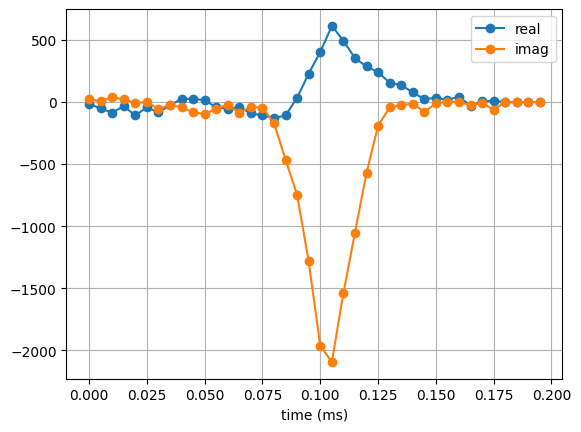

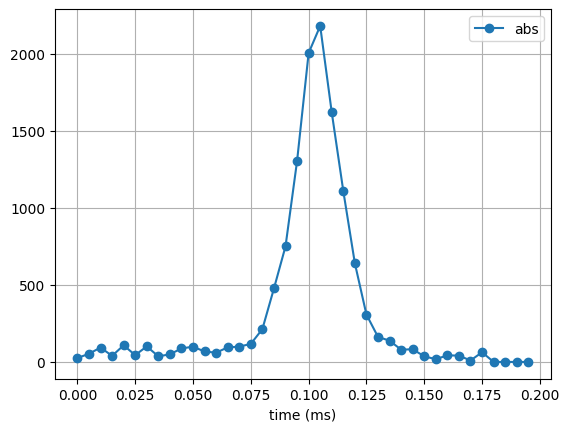

In [3]:
exclude_beginning = 3

# squeeze data and average across scans
y_MCoff = np.mean(raw_data_MCoff[:,:,0,0], axis=1) 
y_MCon = np.mean(raw_data_MCon[:,:,0,0], axis=1)

# time axis for one echo
t_echo = np.linspace(0, (echo_points - 1) * dwell_time, echo_points) * 1e3

# plotting first echo skipping the first 3 echos
plt.plot(t_echo, y_MCoff[echo_points*exclude_beginning : echo_points*(exclude_beginning+1)].real, label = 'real', marker = 'o')
plt.plot(t_echo, y_MCoff[echo_points*exclude_beginning : echo_points*(exclude_beginning+1)].imag, label = 'imag', marker = 'o')
plt.legend()
plt.grid()
plt.xlabel('time (ms)')
plt.show()

plt.plot(t_echo, np.abs(y_MCoff[echo_points*exclude_beginning : echo_points*(exclude_beginning+1)]), label = 'abs', marker = 'o')
plt.legend()
plt.grid()
plt.xlabel('time (ms)')
plt.show()

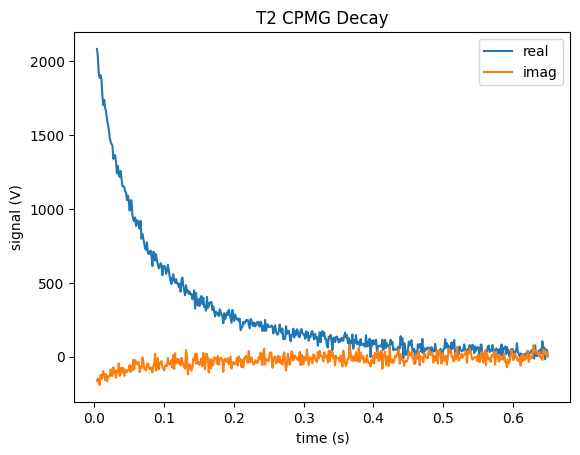

In [4]:
# phase correction
def phaseShift(y, echoPts):
    fifthEcho = y[echoPts * exclude_beginning : echoPts * (exclude_beginning+1)]
    peak_index = np.argmax(np.abs(fifthEcho)) + (2 * echoPts)
    peak_value = y[peak_index]

    phase_correction = np.exp(-1j * np.angle(peak_value))

    if (peak_value * phase_correction).real < 0:
        phase_correction *= np.exp(1j * np.pi)

    return phase_correction

phase_shift_MCoff = phaseShift(y_MCoff, echo_points)
y_corrected_MCoff = y_MCoff * phase_shift_MCoff

phase_shift_MCon = phaseShift(y_MCon, echo_points)
y_corrected_MCon = y_MCon * phase_shift_MCon


# Reshape into a 2D array where each row corresponds to an echo
y_reshaped_MCoff = np.reshape(y_corrected_MCoff, (-1, echo_points))  # (num_echos, echo_points)
y_reshaped_MCon = np.reshape(y_corrected_MCon, (-1, echo_points))  # (num_echos, echo_points)

# Indices to average in one echo
idx = [20, 21]

# Compute one value for each echo
y_int_MCoff = np.mean(y_reshaped_MCoff[:, idx], axis=1)
y_int_MCon = np.mean(y_reshaped_MCon[:, idx], axis=1)

# Exclude initial echos with artifacts
y_int_MCoff = y_int_MCoff[exclude_beginning:]
y_int_MCon = y_int_MCon[exclude_beginning:]

# time axis
t_int = np.linspace(0, num_echoes*(2*tau), num_echoes)
t_int = t_int[exclude_beginning:]

# T2 decay
plt.plot(t_int, y_int_MCoff.real, label = 'real')
plt.plot(t_int, y_int_MCoff.imag, label = 'imag')
plt.ylabel('signal (V)')
plt.xlabel('time (s)')
plt.title('T2 CPMG Decay')
plt.legend()
plt.show()

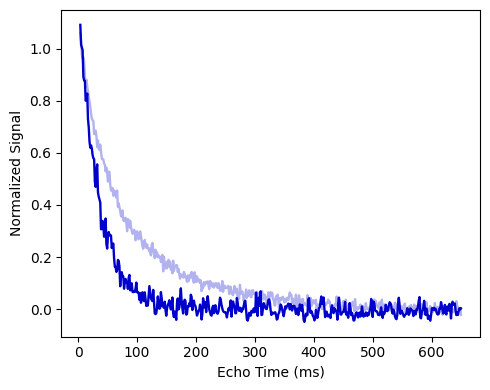

MC off T2 = 85.1 ms
MC on T2  = 33.8 ms


In [7]:
# Denoise for better visualization
#y_T2_MCoff = wiener(np.abs(y_int_MCoff), mysize=2)
y_T2_MCoff = np.abs(y_int_MCoff)

y_T2_MCon = wiener(np.abs(y_int_MCon), mysize=2)
#y_T2_MCon = np.abs(y_int_MCon)

# time axis
t_cpmg = t_int

# --- DC offsets ---
offset_MCoff = np.mean(y_T2_MCoff[-20:])
offset_MCon  = np.mean(y_T2_MCon[-20:])


# --- Exponential models ---
def cpmg_exp_decay_MCoff(t, b, T2):
    return offset_MCoff + b * np.exp(-t / T2)


def cpmg_exp_decay_MCon(t, b, T2):
    return offset_MCon + b * np.exp(-t / T2)


# --- Initial guesses ---
target_MCoff = offset_MCoff + 0.3 * (y_T2_MCoff[0] - offset_MCoff)
target_MCon  = offset_MCon  + 0.3 * (y_T2_MCon[0] - offset_MCon)

T2_guess_MCoff = t_cpmg[
    np.argmin(np.abs(y_T2_MCoff - target_MCoff))
]

T2_guess_MCon = t_cpmg[
    np.argmin(np.abs(y_T2_MCon - target_MCon))
]


# --- Fit original T2 data ---
popt_MCoff, pcov_MCoff = curve_fit(
    cpmg_exp_decay_MCoff,
    t_cpmg,
    y_T2_MCoff,
    p0=[y_T2_MCoff[0] - offset_MCoff, T2_guess_MCoff]
)

popt_MCon, pcov_MCon = curve_fit(
    cpmg_exp_decay_MCon,
    t_cpmg,
    y_T2_MCon,
    p0=[y_T2_MCon[0] - offset_MCon, T2_guess_MCon]
)

b_MCoff, T2_fit_MCoff = popt_MCoff
b_MCon, T2_fit_MCon = popt_MCon


# --- Normalize separately for visualization ---
# Subtract each DC offset, then normalize by the first 5 points.
y_MCoff_norm = (
    (y_T2_MCoff - offset_MCoff) /
    np.mean(y_T2_MCoff[:5] - offset_MCoff)
)

y_MCon_norm = (
    (y_T2_MCon - offset_MCon) /
    np.mean(y_T2_MCon[:5] - offset_MCon)
)


# --- Plot normalized data only ---
plt.figure(figsize=(5, 4))

plt.plot(
    t_cpmg * 1000,
    y_MCoff_norm,
    color="mediumblue",
    alpha=0.3,
    linewidth=1.7,
    label="MC off"
)

plt.plot(
    t_cpmg * 1000,
    y_MCon_norm,
    color="mediumblue",
    linewidth=1.7,
    label="MC on"
)

plt.xlabel("Echo Time (ms)")
plt.ylabel("Normalized Signal")
#plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


# --- Print fitted T2 values ---
print(f"MC off T2 = {1000*T2_fit_MCoff:.1f} ms")
print(f"MC on T2  = {1000*T2_fit_MCon:.1f} ms")